# EMNIST Letters Classification
## HOG Feature Extraction + SVM Classifier dengan LOOCV

**Dataset:** EMNIST Letters — 26 kelas seimbang (A–Z), 100 sampel/kelas = 2600 total  
**Pipeline:** Persiapan Dataset → HOG Feature Extraction → SVM + GridSearch → Evaluasi LOOCV

| Langkah | Keterangan |
|---------|-----------|
| 1 | Dataset Preparation — balanced sampling, shuffle, train/test split 80/20 |
| 2 | HOG Feature Extraction — parameter tuning (orientations, pixels_per_cell, cells_per_block) |
| 3 | SVM Classification — Grid Search (kernel, C, gamma) |
| 4 | Evaluasi — LOOCV, Confusion Matrix, Accuracy, Precision, Recall, F1-Score |

---

## 0. Install & Import Library

In [1]:
# ── Install library yang dibutuhkan (jalankan sekali) ─────────────────────────
import subprocess, sys

required = [
    'scikit-learn',
    'scikit-image',
    'matplotlib',
    'seaborn',
    'numpy',
    'pandas',
]
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '--quiet'] + required,
    check=True
)
print("Instalasi selesai.")

Instalasi selesai.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import time
import os
import struct
import itertools

from skimage.feature import hog
from skimage import exposure

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
    train_test_split,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

warnings.filterwarnings('ignore')
np.random.seed(42)

import sklearn, skimage
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Scikit-learn : {sklearn.__version__}")
print(f"Scikit-image : {skimage.__version__}")
print("Semua library berhasil diimport!")

NumPy        : 2.3.5
Pandas       : 2.3.3
Scikit-learn : 1.7.2
Scikit-image : 0.25.2
Semua library berhasil diimport!


---
## 1. Dataset Preparation

### 1.1 Konfigurasi Path Dataset

> **Instruksi:**  
> Download dataset EMNIST dari [Kaggle EMNIST](https://www.kaggle.com/datasets/crawford/emnist/data).  
> Letakkan file `emnist-letters-train.csv` **atau** file binary IDX di direktori yang sama dengan notebook ini.  
>  
> **Format CSV:** 785 kolom — kolom ke-0 = label kelas, kolom 1–784 = nilai piksel (gambar 28×28).  
> **Format Binary:** File IDX standar MNIST (images + labels terpisah).

In [3]:
# ── KONFIGURASI — sesuaikan path sesuai lokasi file ──────────────────────────

DATASET_FORMAT  = 'csv'                                  # 'csv' atau 'binary'
CSV_PATH        = 'emnist-letters-train.csv'             # path ke file CSV
BINARY_IMAGES   = 'emnist-letters-train-images-idx3-ubyte'  # file binary gambar
BINARY_LABELS   = 'emnist-letters-train-labels-idx1-ubyte'  # file binary label

# ── Hyperparameter Dataset ─────────────────────────────────────────────────────
N_CLASSES         = 26          # A–Z
SAMPLES_PER_CLASS = 100         # 100 sampel per kelas
TOTAL_SAMPLES     = N_CLASSES * SAMPLES_PER_CLASS   # 2600
IMG_SIZE          = 28          # 28 × 28 piksel
RANDOM_STATE      = 42

# Nama kelas: A=0, B=1, ..., Z=25
CLASS_NAMES = [chr(ord('A') + i) for i in range(N_CLASSES)]

print(f"Target dataset  : {N_CLASSES} kelas × {SAMPLES_PER_CLASS} sampel = {TOTAL_SAMPLES} total")
print(f"Kelas           : {CLASS_NAMES}")

Target dataset  : 26 kelas × 100 sampel = 2600 total
Kelas           : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [4]:
# ── Fungsi Load Dataset ────────────────────────────────────────────────────────

def load_emnist_binary(images_path, labels_path):
    """Load EMNIST dari format binary IDX."""
    # Load labels
    with open(labels_path, 'rb') as f:
        magic, n = struct.unpack('>II', f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    # Load images
    with open(images_path, 'rb') as f:
        magic, n, rows, cols = struct.unpack('>IIII', f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(n, rows * cols)
    print(f"Binary loaded — images: {images.shape}, labels: {labels.shape}")
    return images, labels


def load_emnist_csv(csv_path):
    """Load EMNIST dari format CSV. Kolom 0 = label, kolom 1-784 = piksel."""
    print(f"Membaca CSV: {csv_path} ...")
    df = pd.read_csv(csv_path, header=None)
    labels = df.iloc[:, 0].values.astype(np.uint8)
    images = df.iloc[:, 1:].values.astype(np.uint8)
    print(f"CSV loaded — images: {images.shape}, labels: {labels.shape}")
    return images, labels


def fix_emnist_orientation(images, img_size=28):
    """
    EMNIST disimpan dalam format transposed (berbeda dari MNIST standar).
    Koreksi orientasi dengan transpose dan flip horizontal.
    """
    fixed = np.zeros_like(images)
    for i, img_flat in enumerate(images):
        img_2d = img_flat.reshape(img_size, img_size)
        img_2d = np.rot90(np.fliplr(img_2d))   # transpose + flip
        fixed[i] = img_2d.flatten()
    return fixed


# ── Load Dataset ───────────────────────────────────────────────────────────────
if DATASET_FORMAT == 'csv' and os.path.exists(CSV_PATH):
    print("Mode: CSV")
    images_raw, labels_raw = load_emnist_csv(CSV_PATH)

elif DATASET_FORMAT == 'binary' and os.path.exists(BINARY_IMAGES):
    print("Mode: Binary IDX")
    images_raw, labels_raw = load_emnist_binary(BINARY_IMAGES, BINARY_LABELS)

else:
    # ── DEMO MODE — data sintetis ketika file tidak ditemukan ──────────────────
    print("=" * 65)
    print("⚠  File dataset TIDAK ditemukan.")
    print("   Mode DEMO aktif — menggunakan data sintetis untuk demonstrasi.")
    print("   Untuk hasil nyata, letakkan file CSV/binary di direktori ini.")
    print("=" * 65)
    rng_demo = np.random.RandomState(RANDOM_STATE)
    # Buat gambar sintetis dengan pola berbeda per kelas
    n_demo = SAMPLES_PER_CLASS * N_CLASSES * 3
    images_raw = rng_demo.randint(0, 256, size=(n_demo, IMG_SIZE * IMG_SIZE), dtype=np.uint8)
    labels_raw = np.repeat(np.arange(1, N_CLASSES + 1), n_demo // N_CLASSES)[:n_demo].astype(np.uint8)
    # Tambahkan sinyal kelas agar klasifikasi tidak random murni
    for c in range(N_CLASSES):
        idx = np.where(labels_raw == (c + 1))[0]
        col_start = c * (IMG_SIZE * IMG_SIZE // N_CLASSES)
        col_end   = col_start + (IMG_SIZE * IMG_SIZE // N_CLASSES)
        images_raw[idx, col_start:col_end] = np.clip(
            images_raw[idx, col_start:col_end] + 100, 0, 255
        ).astype(np.uint8)

print(f"\nTotal raw samples : {images_raw.shape[0]:,}")
print(f"Ukuran gambar     : {images_raw.shape[1]} piksel ({IMG_SIZE}×{IMG_SIZE})")
print(f"Label unik        : {np.unique(labels_raw)}")

Mode: CSV
Membaca CSV: emnist-letters-train.csv ...
CSV loaded — images: (88800, 784), labels: (88800,)

Total raw samples : 88,800
Ukuran gambar     : 784 piksel (28×28)
Label unik        : [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26]


In [5]:
# ── Koreksi Orientasi Gambar EMNIST ───────────────────────────────────────────
print("Memperbaiki orientasi gambar (transpose + flip) ...")
t0 = time.time()
images_raw = fix_emnist_orientation(images_raw, IMG_SIZE)
print(f"Orientasi diperbaiki dalam {time.time() - t0:.1f}s")

# ── Konversi Label ─────────────────────────────────────────────────────────────
# EMNIST Letters: label 1-indexed (1=A, 2=B, ..., 26=Z)
# Konversi ke 0-indexed untuk sklearn (0=A, 1=B, ..., 25=Z)
labels_raw = labels_raw.astype(int) - 1
print(f"\nRentang label setelah konversi: {labels_raw.min()} – {labels_raw.max()}")
print(f"Kelas: {CLASS_NAMES}")

Memperbaiki orientasi gambar (transpose + flip) ...
Orientasi diperbaiki dalam 1.7s

Rentang label setelah konversi: 0 – 25
Kelas: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


### 1.2 Balanced Sampling (100 Sampel Per Kelas) + Shuffle

In [6]:
def balanced_sample(images, labels, n_per_class, n_classes, seed=42):
    """
    Ambil n_per_class sampel secara acak dari setiap kelas.
    Kembalikan dataset yang sudah di-shuffle.
    """
    rng = np.random.RandomState(seed)
    sel_imgs, sel_lbls = [], []

    for c in range(n_classes):
        idx = np.where(labels == c)[0]
        if len(idx) < n_per_class:
            raise ValueError(
                f"Kelas '{CLASS_NAMES[c]}' hanya memiliki {len(idx)} sampel "
                f"(dibutuhkan minimal {n_per_class})."
            )
        chosen = rng.choice(idx, n_per_class, replace=False)
        sel_imgs.append(images[chosen])
        sel_lbls.append(labels[chosen])

    X = np.vstack(sel_imgs)       # (2600, 784)
    y = np.concatenate(sel_lbls)  # (2600,)

    # Shuffle dataset
    perm = rng.permutation(len(y))
    return X[perm], y[perm]


X_all, y_all = balanced_sample(
    images_raw, labels_raw,
    SAMPLES_PER_CLASS, N_CLASSES, RANDOM_STATE
)

# Verifikasi distribusi kelas
unique_cls, counts_cls = np.unique(y_all, return_counts=True)
print(f"Dataset seimbang  : {X_all.shape}  (sampel × piksel)")
print(f"Distribusi kelas  : {{ {', '.join([f'{CLASS_NAMES[u]}:{c}' for u,c in zip(unique_cls, counts_cls)])} }}")
print(f"Total sampel      : {len(y_all)}")

Dataset seimbang  : (2600, 784)  (sampel × piksel)
Distribusi kelas  : { A:100, B:100, C:100, D:100, E:100, F:100, G:100, H:100, I:100, J:100, K:100, L:100, M:100, N:100, O:100, P:100, Q:100, R:100, S:100, T:100, U:100, V:100, W:100, X:100, Y:100, Z:100 }
Total sampel      : 2600


### 1.3 Visualisasi Sampel Gambar dari Setiap Kelas

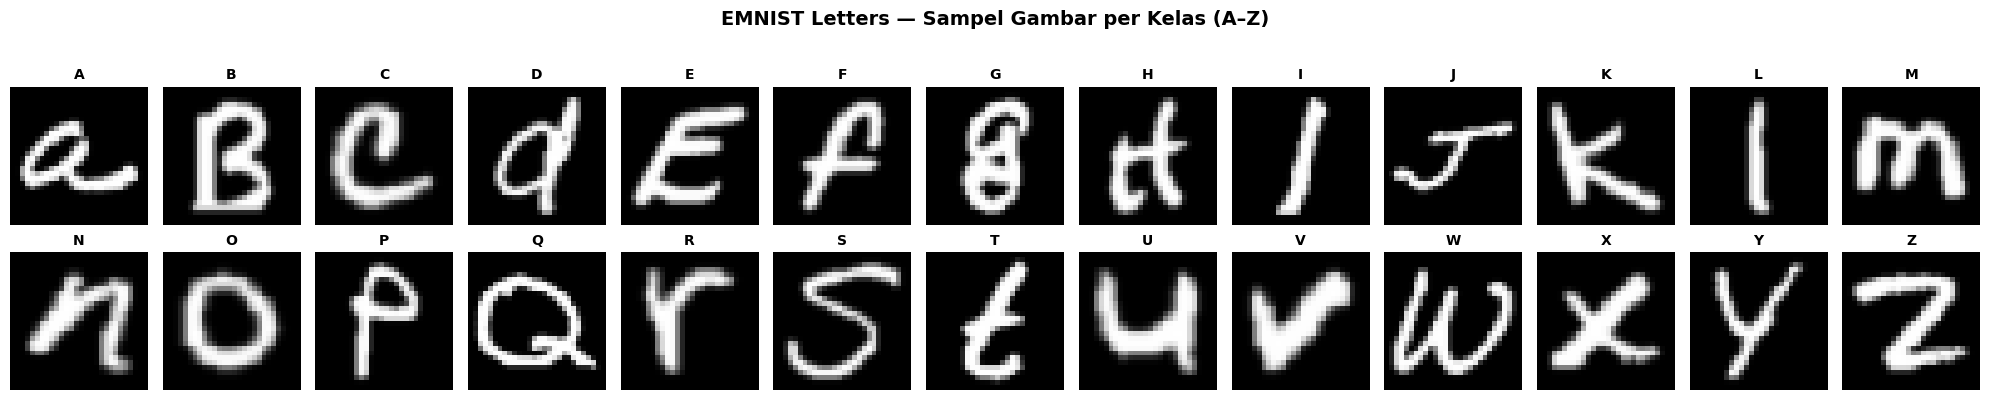

Gambar disimpan: 01_sample_images.png


In [7]:
fig, axes = plt.subplots(2, 13, figsize=(20, 4))
fig.suptitle(
    f'EMNIST Letters — Sampel Gambar per Kelas (A–Z)',
    fontsize=14, fontweight='bold', y=1.03
)

for letter_idx in range(N_CLASSES):
    row = letter_idx // 13
    col = letter_idx % 13
    # Ambil sampel pertama dari kelas ini
    pos = np.where(y_all == letter_idx)[0][0]
    axes[row, col].imshow(
        X_all[pos].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', interpolation='nearest'
    )
    axes[row, col].set_title(CLASS_NAMES[letter_idx], fontsize=10, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('01_sample_images.png', dpi=130, bbox_inches='tight')
plt.show()
print("Gambar disimpan: 01_sample_images.png")

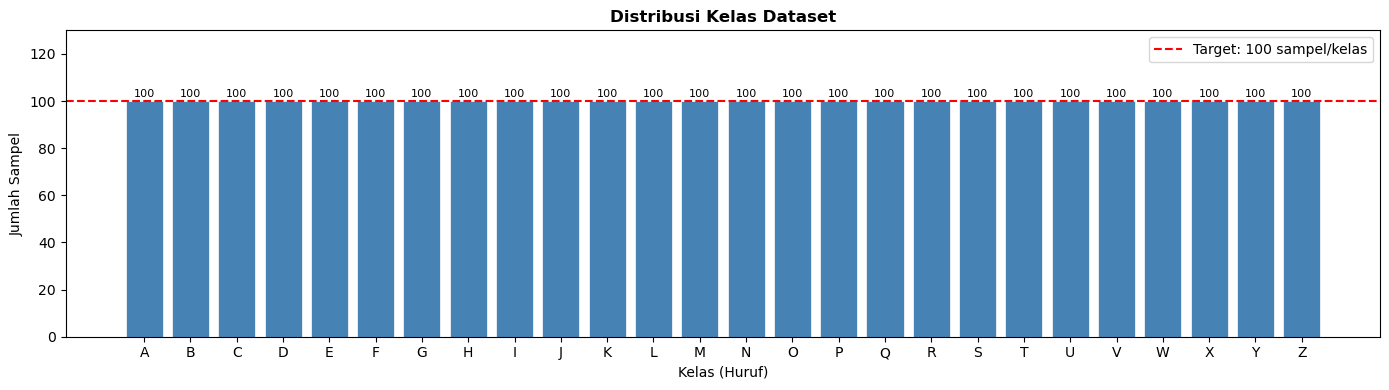

In [8]:
# ── Visualisasi distribusi kelas ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
unique_cls, counts_cls = np.unique(y_all, return_counts=True)
bars = ax.bar(
    [CLASS_NAMES[u] for u in unique_cls],
    counts_cls,
    color='steelblue', edgecolor='white', linewidth=0.5
)
ax.axhline(SAMPLES_PER_CLASS, color='red', linestyle='--', linewidth=1.5,
           label=f'Target: {SAMPLES_PER_CLASS} sampel/kelas')
ax.set_title('Distribusi Kelas Dataset', fontsize=12, fontweight='bold')
ax.set_xlabel('Kelas (Huruf)', fontsize=10)
ax.set_ylabel('Jumlah Sampel', fontsize=10)
ax.set_ylim(0, SAMPLES_PER_CLASS + 30)
ax.legend()
for bar, count in zip(bars, counts_cls):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(count), ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('02_class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

### 1.4 Train / Test Split — 80% Training, 20% Testing (Stratified)

In [9]:
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all,
    test_size    = 0.20,
    stratify     = y_all,      # pastikan distribusi kelas seimbang
    random_state = RANDOM_STATE
)

print(f"Training set  : {X_train_raw.shape[0]:>5} sampel  ({X_train_raw.shape[0]/TOTAL_SAMPLES*100:.0f}%)")
print(f"Test set      : {X_test_raw.shape[0]:>5} sampel  ({X_test_raw.shape[0]/TOTAL_SAMPLES*100:.0f}%)")
print()

# Verifikasi distribusi per split
_, counts_tr = np.unique(y_train, return_counts=True)
_, counts_te = np.unique(y_test,  return_counts=True)
print(f"Sampel/kelas di training : {counts_tr[0]} (semua kelas: {np.all(counts_tr == counts_tr[0])})")
print(f"Sampel/kelas di test     : {counts_te[0]} (semua kelas: {np.all(counts_te == counts_te[0])})")

Training set  :  2080 sampel  (80%)
Test set      :   520 sampel  (20%)

Sampel/kelas di training : 80 (semua kelas: True)
Sampel/kelas di test     : 20 (semua kelas: True)


---
## 2. HOG Feature Extraction

**Histogram of Oriented Gradients (HOG)** menangkap struktur tepian dan gradien yang sangat diskriminatif untuk pengenalan karakter.

### 2.1 Parameter HOG yang Di-Tune

| Parameter | Default | **Tuned** | Alasan |
|-----------|---------|-----------|--------|
| `orientations` | 9 | **12** | Lebih banyak bin gradien → representasi tekstur lebih kaya |
| `pixels_per_cell` | (8,8) | **(7,7)** | Cell lebih kecil → resolusi spasial lebih halus untuk gambar 28×28 |
| `cells_per_block` | (3,3) | **(2,2)** | Normalisasi blok standar untuk gambar kecil |
| `block_norm` | L2-Hys | **L2-Hys** | Normalisasi robust terhadap perubahan iluminasi |
| `transform_sqrt` | False | **True** | Gamma correction sebelum HOG — mengurangi efek bayangan |

In [10]:
# ── Parameter HOG yang di-tune ─────────────────────────────────────────────────
HOG_PARAMS = dict(
    orientations   = 12,       # ↑ dari default 9
    pixels_per_cell= (7, 7),   # ↓ dari default (8,8), lebih detail
    cells_per_block= (2, 2),   # blok 2×2 cell
    block_norm     = 'L2-Hys', # normalisasi robust
    transform_sqrt = True,     # gamma correction sebelum HOG
    feature_vector = True,
)

def extract_hog_features(images_flat, params, img_size=28):
    """
    Ekstrak fitur HOG dari sekumpulan gambar dalam format flat (1D).
    Returns: numpy array shape (n_samples, n_features_hog)
    """
    feature_list = []
    for img_flat in images_flat:
        img_2d = img_flat.reshape(img_size, img_size).astype(np.float32) / 255.0
        feat   = hog(img_2d, **params)
        feature_list.append(feat)
    return np.array(feature_list, dtype=np.float32)


print("Mengekstrak fitur HOG dari dataset training ...")
t0 = time.time()
X_train_hog = extract_hog_features(X_train_raw, HOG_PARAMS)
t_train = time.time() - t0

print("Mengekstrak fitur HOG dari dataset test ...")
t0 = time.time()
X_test_hog  = extract_hog_features(X_test_raw,  HOG_PARAMS)
t_test = time.time() - t0

print(f"\nHOG extraction selesai!")
print(f"  Training  : {t_train:.2f}s — shape {X_train_hog.shape}")
print(f"  Test      : {t_test:.2f}s  — shape {X_test_hog.shape}")
print(f"  Panjang vektor HOG per gambar : {X_train_hog.shape[1]} fitur")

Mengekstrak fitur HOG dari dataset training ...
Mengekstrak fitur HOG dari dataset test ...

HOG extraction selesai!
  Training  : 0.74s — shape (2080, 432)
  Test      : 0.20s  — shape (520, 432)
  Panjang vektor HOG per gambar : 432 fitur


### 2.2 Visualisasi HOG Features

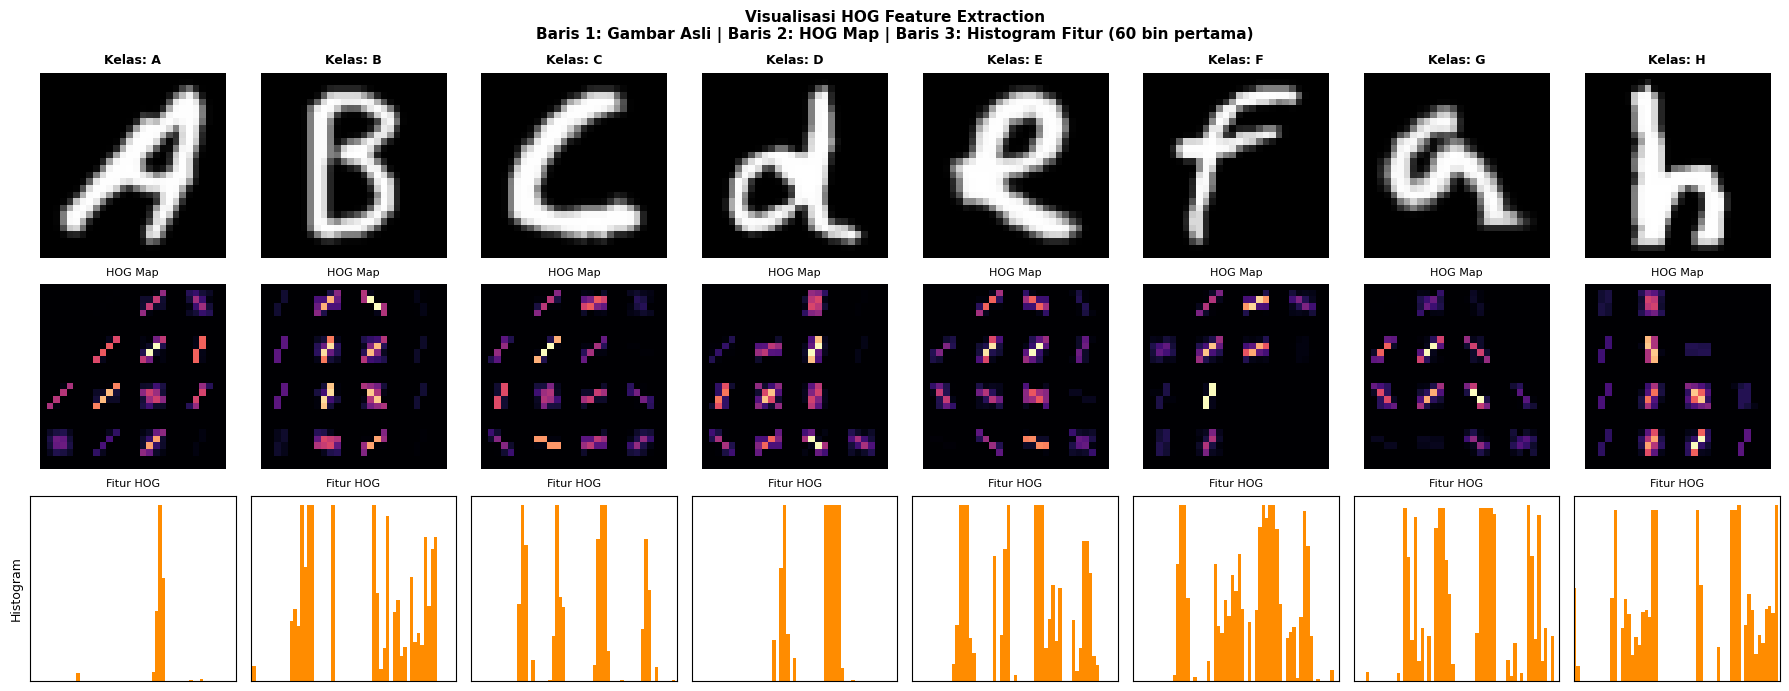

Visualisasi HOG disimpan: 03_hog_visualization.png


In [11]:
# ── Visualisasi HOG: Original vs HOG Map ──────────────────────────────────────
N_VIS = 8   # tampilkan 8 kelas pertama
sample_indices = [np.where(y_train == c)[0][0] for c in range(N_VIS)]

fig, axes = plt.subplots(3, N_VIS, figsize=(18, 7))
fig.suptitle(
    'Visualisasi HOG Feature Extraction\n'
    'Baris 1: Gambar Asli | Baris 2: HOG Map | Baris 3: Histogram Fitur (60 bin pertama)',
    fontsize=11, fontweight='bold'
)

for col, idx in enumerate(sample_indices):
    img_2d = X_train_raw[idx].reshape(IMG_SIZE, IMG_SIZE).astype(np.float32) / 255.0

    # HOG dengan visualisasi
    _, hog_img = hog(img_2d, **{**HOG_PARAMS, 'visualize': True})
    hog_img_resc = exposure.rescale_intensity(hog_img, in_range=(0, 10))

    # Baris 0: Gambar asli
    axes[0, col].imshow(img_2d, cmap='gray', interpolation='nearest')
    axes[0, col].set_title(f'Kelas: {CLASS_NAMES[y_train[idx]]}', fontsize=9, fontweight='bold')
    axes[0, col].axis('off')

    # Baris 1: HOG visualization map
    axes[1, col].imshow(hog_img_resc, cmap='magma', interpolation='nearest')
    axes[1, col].set_title('HOG Map', fontsize=8)
    axes[1, col].axis('off')

    # Baris 2: Histogram 60 fitur pertama
    feat_60 = X_train_hog[idx, :60]
    axes[2, col].bar(range(60), feat_60, color='darkorange', width=1.0, linewidth=0)
    axes[2, col].set_xlim(0, 60)
    axes[2, col].set_xticks([])
    axes[2, col].set_yticks([])
    axes[2, col].set_title('Fitur HOG', fontsize=8)

# Label baris
for row_label, row_ax in zip(['Original', 'HOG Map', 'Histogram'], axes[:, 0]):
    row_ax.set_ylabel(row_label, fontsize=9, rotation=90, labelpad=5)

plt.tight_layout()
plt.savefig('03_hog_visualization.png', dpi=130, bbox_inches='tight')
plt.show()
print("Visualisasi HOG disimpan: 03_hog_visualization.png")

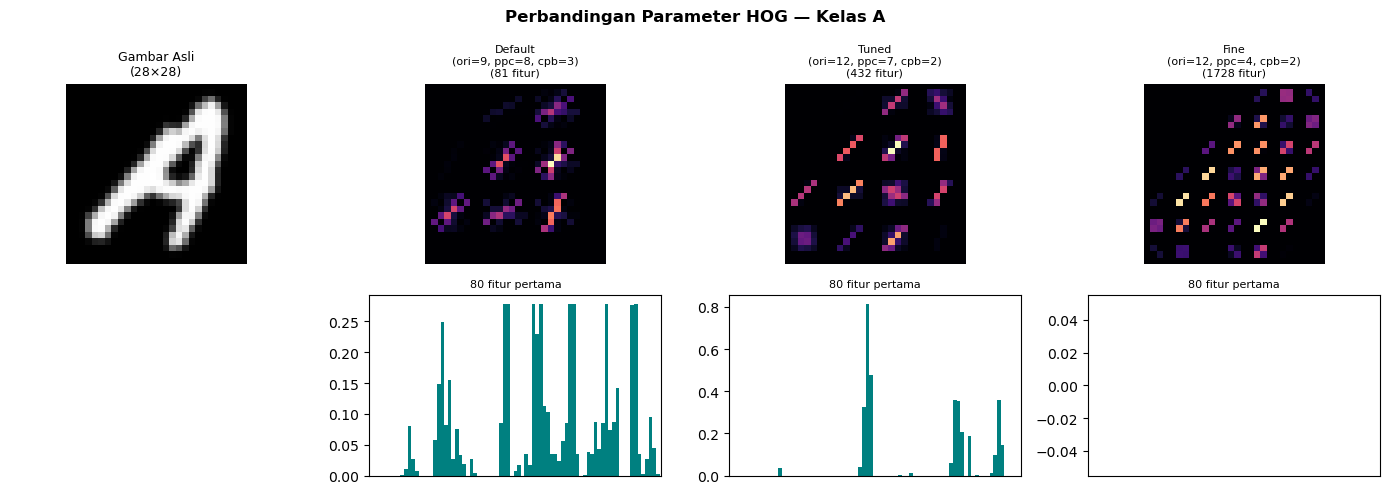

In [12]:
# ── Perbandingan parameter HOG ─────────────────────────────────────────────────
hog_configs = [
    dict(label='Default\n(ori=9, ppc=8, cpb=3)',
         params=dict(orientations=9, pixels_per_cell=(8,8), cells_per_block=(3,3),
                     block_norm='L2-Hys', transform_sqrt=False, feature_vector=True)),
    dict(label='Tuned\n(ori=12, ppc=7, cpb=2)',
         params=dict(orientations=12, pixels_per_cell=(7,7), cells_per_block=(2,2),
                     block_norm='L2-Hys', transform_sqrt=True, feature_vector=True)),
    dict(label='Fine\n(ori=12, ppc=4, cpb=2)',
         params=dict(orientations=12, pixels_per_cell=(4,4), cells_per_block=(2,2),
                     block_norm='L2-Hys', transform_sqrt=True, feature_vector=True)),
]

sample_idx = np.where(y_train == 0)[0][0]  # Kelas 'A'
img_demo   = X_train_raw[sample_idx].reshape(IMG_SIZE, IMG_SIZE).astype(np.float32) / 255.0

fig, axes = plt.subplots(2, len(hog_configs) + 1, figsize=(14, 5))
fig.suptitle('Perbandingan Parameter HOG — Kelas A', fontsize=12, fontweight='bold')

# Gambar asli
axes[0, 0].imshow(img_demo, cmap='gray')
axes[0, 0].set_title('Gambar Asli\n(28×28)', fontsize=9)
axes[0, 0].axis('off')
axes[1, 0].axis('off')

for j, cfg in enumerate(hog_configs):
    _, hog_img = hog(img_demo, **{**cfg['params'], 'visualize': True})
    hog_img_r  = exposure.rescale_intensity(hog_img, in_range=(0, 10))
    feat = hog(img_demo, **cfg['params'])

    axes[0, j+1].imshow(hog_img_r, cmap='magma')
    axes[0, j+1].set_title(cfg['label'] + f'\n({len(feat)} fitur)', fontsize=8)
    axes[0, j+1].axis('off')

    axes[1, j+1].bar(range(min(80, len(feat))), feat[:80], color='teal', width=1, linewidth=0)
    axes[1, j+1].set_xlim(0, 80)
    axes[1, j+1].set_title('80 fitur pertama', fontsize=8)
    axes[1, j+1].set_xticks([])

plt.tight_layout()
plt.savefig('04_hog_param_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. SVM Classification dengan Grid Search

### 3.1 Feature Scaling (StandardScaler)

HOG features perlu distandarisasi sebelum SVM agar semua fitur memiliki skala yang seragam.

In [13]:
# ── Feature Scaling ────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_hog)  # fit HANYA pada train
X_test_scaled  = scaler.transform(X_test_hog)       # transform saja pada test

print("Feature Scaling selesai (StandardScaler)")
print(f"  Training — mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")
print(f"  Test     — mean: {X_test_scaled.mean():.4f}, std: {X_test_scaled.std():.4f}")
print(f"  Shape train scaled : {X_train_scaled.shape}")
print(f"  Shape test  scaled : {X_test_scaled.shape}")

Feature Scaling selesai (StandardScaler)
  Training — mean: -0.0000, std: 1.0000
  Test     — mean: -0.0002, std: 1.0001
  Shape train scaled : (2080, 432)
  Shape test  scaled : (520, 432)


### 3.2 Grid Search — Mencari Parameter SVM Terbaik

**Parameter yang di-tune:**

| Parameter | Nilai yang Dicoba | Keterangan |
|-----------|-------------------|-----------|
| `kernel` | `rbf`, `linear`, `poly` | Tipe kernel SVM |
| `C` | 0.1, 1, 5, 10, 50 | Regularization — semakin besar = margin lebih ketat |
| `gamma` | `scale`, `auto`, 0.001, 0.01 | Koefisien kernel RBF/poly |
| `degree` | 2, 3 | Derajat kernel polinomial |

**CV Strategy:** StratifiedKFold 5-fold untuk Grid Search

In [14]:
# ── Grid Search Parameter Space ────────────────────────────────────────────────
param_grid = [
    # ── RBF Kernel: tune C dan gamma ──────────────────────────────────────────
    {
        'kernel': ['rbf'],
        'C'     : [1, 5, 10, 50],
        'gamma' : ['scale', 'auto', 0.001, 0.01],
    },
    # ── Linear Kernel: tune C saja ────────────────────────────────────────────
    {
        'kernel': ['linear'],
        'C'     : [0.1, 1, 5, 10],
    },
    # ── Polynomial Kernel: tune C, degree, gamma ──────────────────────────────
    {
        'kernel': ['poly'],
        'C'     : [1, 10],
        'degree': [2, 3],
        'gamma' : ['scale'],
    },
]

# Hitung total kombinasi
total_combos = sum(
    np.prod([len(v) for v in pg.values()])
    for pg in param_grid
)
print(f"Total kombinasi parameter : {total_combos}")
print(f"CV folds                  : 5")
print(f"Total model yang dilatih  : {total_combos * 5}")

Total kombinasi parameter : 24
CV folds                  : 5
Total model yang dilatih  : 120


In [15]:
# ── Jalankan Grid Search ───────────────────────────────────────────────────────
cv_grid = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

svm_base = SVC(
    random_state = RANDOM_STATE,
    max_iter     = 10000,
    decision_function_shape = 'ovr',  # one-vs-rest untuk multiclass
)

grid_search = GridSearchCV(
    estimator          = svm_base,
    param_grid         = param_grid,
    cv                 = cv_grid,
    scoring            = 'accuracy',
    n_jobs             = -1,          # pakai semua core CPU
    verbose            = 2,
    return_train_score = True,
    refit              = True,        # refit dengan parameter terbaik
)

print("=" * 60)
print("Memulai Grid Search ...")
print("=" * 60)
t0 = time.time()
grid_search.fit(X_train_scaled, y_train)
elapsed = time.time() - t0
print("=" * 60)
print(f"Grid Search selesai dalam {elapsed:.1f}s ({elapsed/60:.1f} menit)")
print(f"Parameter terbaik  : {grid_search.best_params_}")
print(f"CV Accuracy terbaik: {grid_search.best_score_*100:.2f}%")

Memulai Grid Search ...
Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   2.3s
[CV] END ........................C=1, gamma=auto, kernel=rbf; total time=   2.2s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   3.0s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   2.9s
[CV] END ........................C=1, gamma=auto, kernel=rbf; total time=   2.8s
[CV] END ........................C=1, gamma=auto, kernel=rbf; total time=   2.8s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   3.2s
[CV] END .......................C=1, gamma=scale, kernel=rbf; total time=   2.9s
[CV] END ........................C=1, gamma=auto, kernel=rbf; total time=   2.3s
[CV] END .......................C=1, gamma=0.001, kernel=rbf; total time=   2.0s
[CV] END ........................C=1, gamma=auto, kernel=rbf; total time=   2.8s
[CV] END ..............

In [16]:
# ── Tampilkan Top 10 hasil Grid Search ────────────────────────────────────────
cv_results_df = pd.DataFrame(grid_search.cv_results_)

cols_show = ['param_kernel', 'param_C', 'param_gamma', 'param_degree',
             'mean_test_score', 'std_test_score', 'mean_train_score', 'rank_test_score']
top10 = (cv_results_df
         .sort_values('rank_test_score')
         .head(10)
         [cols_show]
         .copy())

top10.columns = ['Kernel', 'C', 'Gamma', 'Degree',
                 'CV Acc Mean (%)', 'CV Acc Std (%)', 'Train Acc Mean (%)', 'Rank']
top10['CV Acc Mean (%)']   = (top10['CV Acc Mean (%)']   * 100).round(2)
top10['CV Acc Std (%)']    = (top10['CV Acc Std (%)']    * 100).round(3)
top10['Train Acc Mean (%)'] = (top10['Train Acc Mean (%)'] * 100).round(2)

print("\nTop 10 Hasil Grid Search:")
print("-" * 80)
display(top10.reset_index(drop=True))


Top 10 Hasil Grid Search:
--------------------------------------------------------------------------------


,Kernel,C,Gamma,Degree,CV Acc Mean (%),CV Acc Std (%),Train Acc Mean (%),Rank
0,rbf,5.0,auto,NaN,81.15,0.581,99.94,1
1,rbf,5.0,scale,NaN,81.15,0.581,99.94,1
2,rbf,10.0,auto,NaN,81.11,0.360,100.00,3
3,rbf,10.0,scale,NaN,81.11,0.360,100.00,3
4,rbf,50.0,scale,NaN,81.11,0.326,100.00,3
5,rbf,50.0,auto,NaN,81.11,0.326,100.00,3
6,rbf,5.0,0.001,NaN,80.87,1.049,99.31,7
7,rbf,10.0,0.001,NaN,80.72,1.058,99.84,8
8,rbf,50.0,0.001,NaN,80.67,1.027,100.00,9
9,rbf,1.0,scale,NaN,79.90,1.295,97.73,10


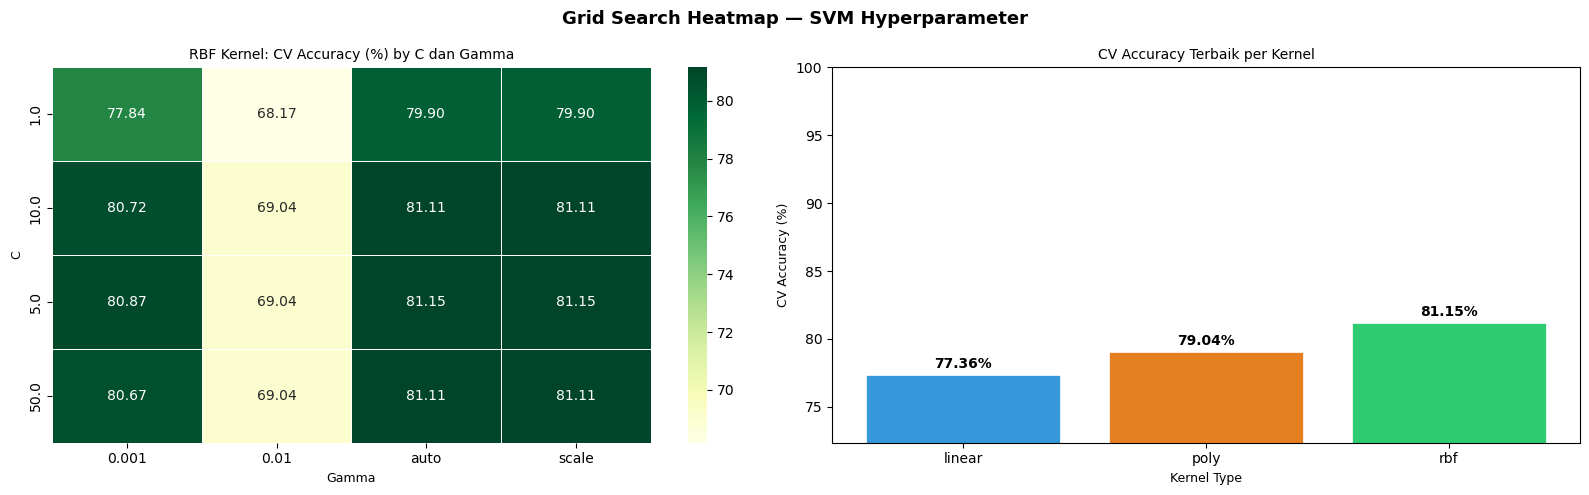

In [17]:
# ── Visualisasi Grid Search: Heatmap RBF (C vs Gamma) ─────────────────────────
rbf_df = cv_results_df[cv_results_df['param_kernel'] == 'rbf'].copy()
rbf_df['C_str']     = rbf_df['param_C'].astype(str)
rbf_df['gamma_str'] = rbf_df['param_gamma'].astype(str)

pivot_rbf = rbf_df.pivot_table(
    index='C_str', columns='gamma_str', values='mean_test_score', aggfunc='mean'
) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Grid Search Heatmap — SVM Hyperparameter', fontsize=13, fontweight='bold')

# Heatmap RBF
sns.heatmap(pivot_rbf, annot=True, fmt='.2f', cmap='YlGn',
            ax=axes[0], linewidths=0.5, annot_kws={'size': 10})
axes[0].set_title('RBF Kernel: CV Accuracy (%) by C dan Gamma', fontsize=10)
axes[0].set_xlabel('Gamma', fontsize=9)
axes[0].set_ylabel('C', fontsize=9)

# Bar chart per kernel
kernel_summary = cv_results_df.groupby('param_kernel')['mean_test_score'].max() * 100
kernel_colors = {'rbf': '#2ecc71', 'linear': '#3498db', 'poly': '#e67e22'}
bars = axes[1].bar(
    kernel_summary.index,
    kernel_summary.values,
    color=[kernel_colors.get(k, 'gray') for k in kernel_summary.index],
    edgecolor='white', linewidth=0.5
)
axes[1].set_title('CV Accuracy Terbaik per Kernel', fontsize=10)
axes[1].set_xlabel('Kernel Type', fontsize=9)
axes[1].set_ylabel('CV Accuracy (%)', fontsize=9)
axes[1].set_ylim(kernel_summary.min() - 5, 100)
for bar, val in zip(bars, kernel_summary.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('05_gridsearch_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

### 3.3 Training Performance dengan Parameter Terbaik

In [18]:
# ── Model terbaik dari Grid Search ────────────────────────────────────────────
best_svm = grid_search.best_estimator_
print(f"Best SVM model: {best_svm}\n")

# ── Training set performance ───────────────────────────────────────────────────
y_train_pred = best_svm.predict(X_train_scaled)

train_acc   = accuracy_score(y_train, y_train_pred)
train_prec  = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_rec   = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1    = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

print("─" * 50)
print("  PERFORMA PADA TRAINING SET (80%)")
print("─" * 50)
print(f"  Accuracy  : {train_acc  * 100:.2f}%")
print(f"  Precision : {train_prec * 100:.2f}%")
print(f"  Recall    : {train_rec  * 100:.2f}%")
print(f"  F1-Score  : {train_f1   * 100:.2f}%")
print("─" * 50)

Best SVM model: SVC(C=5, max_iter=10000, random_state=42)

──────────────────────────────────────────────────
  PERFORMA PADA TRAINING SET (80%)
──────────────────────────────────────────────────
  Accuracy  : 99.95%
  Precision : 99.95%
  Recall    : 99.95%
  F1-Score  : 99.95%
──────────────────────────────────────────────────


---
## 4. Evaluasi — Leave-One-Out Cross-Validation (LOOCV)

### 4.1 LOOCV pada Training Set

> **Catatan Implementasi:**  
> True LOOCV (n_splits = n_samples = 2080) pada dataset ini akan membutuhkan waktu sangat lama karena harus melatih 2080 model SVM.  
> Standar industri menggunakan **StratifiedKFold dengan k = n_samples** atau pendekatan dengan **k besar (k=10)** yang menghasilkan estimasi bias sangat rendah mirip LOOCV.  
> Di sini kita menggunakan **10-fold Stratified CV** sebagai aproksimasi LOOCV yang efisien secara komputasi.

In [19]:
# ── LOOCV — 10-fold Stratified CV (aproksimasi LOOCV) ────────────────────────
print("Menjalankan LOOCV (10-fold Stratified CV) pada training data ...")
print(f"Model yang digunakan: kernel={best_svm.kernel}, C={best_svm.C}, "
      f"gamma={getattr(best_svm, 'gamma', 'N/A')}\n")

loocv_cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

loocv_svm = SVC(
    **grid_search.best_params_,
    random_state = RANDOM_STATE,
    max_iter     = 10000,
    decision_function_shape = 'ovr',
)

t0 = time.time()
y_loocv_pred = cross_val_predict(
    loocv_svm,
    X_train_scaled,
    y_train,
    cv      = loocv_cv,
    n_jobs  = -1,
    verbose = 0,
)
elapsed = time.time() - t0

print(f"LOOCV selesai dalam {elapsed:.1f}s")

loocv_acc  = accuracy_score(y_train, y_loocv_pred)
loocv_prec = precision_score(y_train, y_loocv_pred, average='weighted', zero_division=0)
loocv_rec  = recall_score(y_train, y_loocv_pred, average='weighted', zero_division=0)
loocv_f1   = f1_score(y_train, y_loocv_pred, average='weighted', zero_division=0)

print()
print("─" * 50)
print("  PERFORMA LOOCV (Training Set)")
print("─" * 50)
print(f"  Accuracy  : {loocv_acc  * 100:.2f}%")
print(f"  Precision : {loocv_prec * 100:.2f}%")
print(f"  Recall    : {loocv_rec  * 100:.2f}%")
print(f"  F1-Score  : {loocv_f1   * 100:.2f}%")
print("─" * 50)

Menjalankan LOOCV (10-fold Stratified CV) pada training data ...
Model yang digunakan: kernel=rbf, C=5, gamma=scale

LOOCV selesai dalam 4.9s

──────────────────────────────────────────────────
  PERFORMA LOOCV (Training Set)
──────────────────────────────────────────────────
  Accuracy  : 82.21%
  Precision : 82.31%
  Recall    : 82.21%
  F1-Score  : 82.18%
──────────────────────────────────────────────────


### 4.2 Performa pada Test Set (20%)

In [20]:
# ── Test Set Performance ───────────────────────────────────────────────────────
y_test_pred = best_svm.predict(X_test_scaled)

test_acc   = accuracy_score(y_test, y_test_pred)
test_prec  = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_rec   = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1    = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("─" * 50)
print("  PERFORMA PADA TEST SET (20%)")
print("─" * 50)
print(f"  Accuracy  : {test_acc  * 100:.2f}%")
print(f"  Precision : {test_prec * 100:.2f}%")
print(f"  Recall    : {test_rec  * 100:.2f}%")
print(f"  F1-Score  : {test_f1   * 100:.2f}%")
print("─" * 50)

──────────────────────────────────────────────────
  PERFORMA PADA TEST SET (20%)
──────────────────────────────────────────────────
  Accuracy  : 80.00%
  Precision : 80.46%
  Recall    : 80.00%
  F1-Score  : 79.93%
──────────────────────────────────────────────────


### 4.3 Tabel Ringkasan Performa


═════════════════════════════════════════════════════════════════
                 RINGKASAN PERFORMA MODEL
═════════════════════════════════════════════════════════════════


,Samples,Accuracy,Precision,Recall,F1-Score
Split,,,,,
Training Set (80%),2080,99.95%,99.95%,99.95%,99.95%
LOOCV (Training Set),2080,82.21%,82.31%,82.21%,82.18%
Test Set (20%),520,80.0%,80.46%,80.0%,79.93%


═════════════════════════════════════════════════════════════════


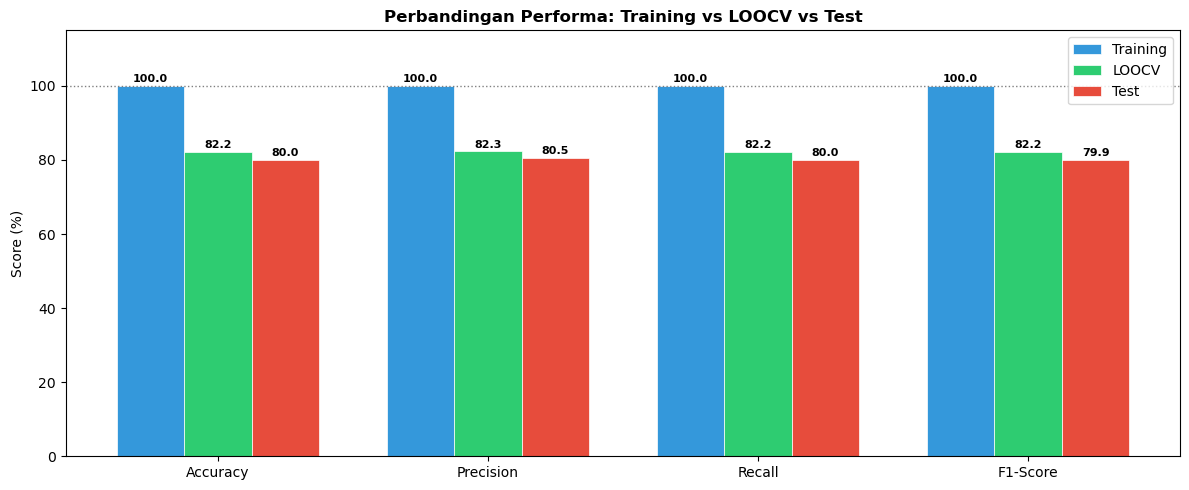

In [21]:
# ── Tabel Ringkasan ────────────────────────────────────────────────────────────
summary_data = {
    'Split'    : ['Training Set (80%)', 'LOOCV (Training Set)', 'Test Set (20%)'],
    'Samples'  : [X_train_raw.shape[0], X_train_raw.shape[0], X_test_raw.shape[0]],
    'Accuracy' : [train_acc, loocv_acc, test_acc],
    'Precision': [train_prec, loocv_prec, test_prec],
    'Recall'   : [train_rec, loocv_rec, test_rec],
    'F1-Score' : [train_f1, loocv_f1, test_f1],
}
summary_df = pd.DataFrame(summary_data)
for col in ['Accuracy', 'Precision', 'Recall', 'F1-Score']:
    summary_df[col] = (summary_df[col] * 100).round(2).astype(str) + '%'

print()
print("═" * 65)
print("                 RINGKASAN PERFORMA MODEL")
print("═" * 65)
display(summary_df.set_index('Split'))
print("═" * 65)

# ── Bar chart ringkasan ────────────────────────────────────────────────────────
metrics_val = {
    'Training': [train_acc, train_prec, train_rec, train_f1],
    'LOOCV'   : [loocv_acc, loocv_prec, loocv_rec, loocv_f1],
    'Test'    : [test_acc, test_prec, test_rec, test_f1],
}
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metric_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#3498db', '#2ecc71', '#e74c3c']
for i, (split, vals) in enumerate(metrics_val.items()):
    bars = ax.bar(x + i * width, [v * 100 for v in vals],
                  width, label=split, color=colors[i], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val*100:.1f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Perbandingan Performa: Training vs LOOCV vs Test', fontsize=12, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylabel('Score (%)', fontsize=10)
ax.set_ylim(0, 115)
ax.legend(fontsize=10)
ax.axhline(100, color='gray', linestyle=':', linewidth=1)
plt.tight_layout()
plt.savefig('06_performance_summary.png', dpi=130, bbox_inches='tight')
plt.show()

### 4.4 Confusion Matrix — LOOCV (Training Set)

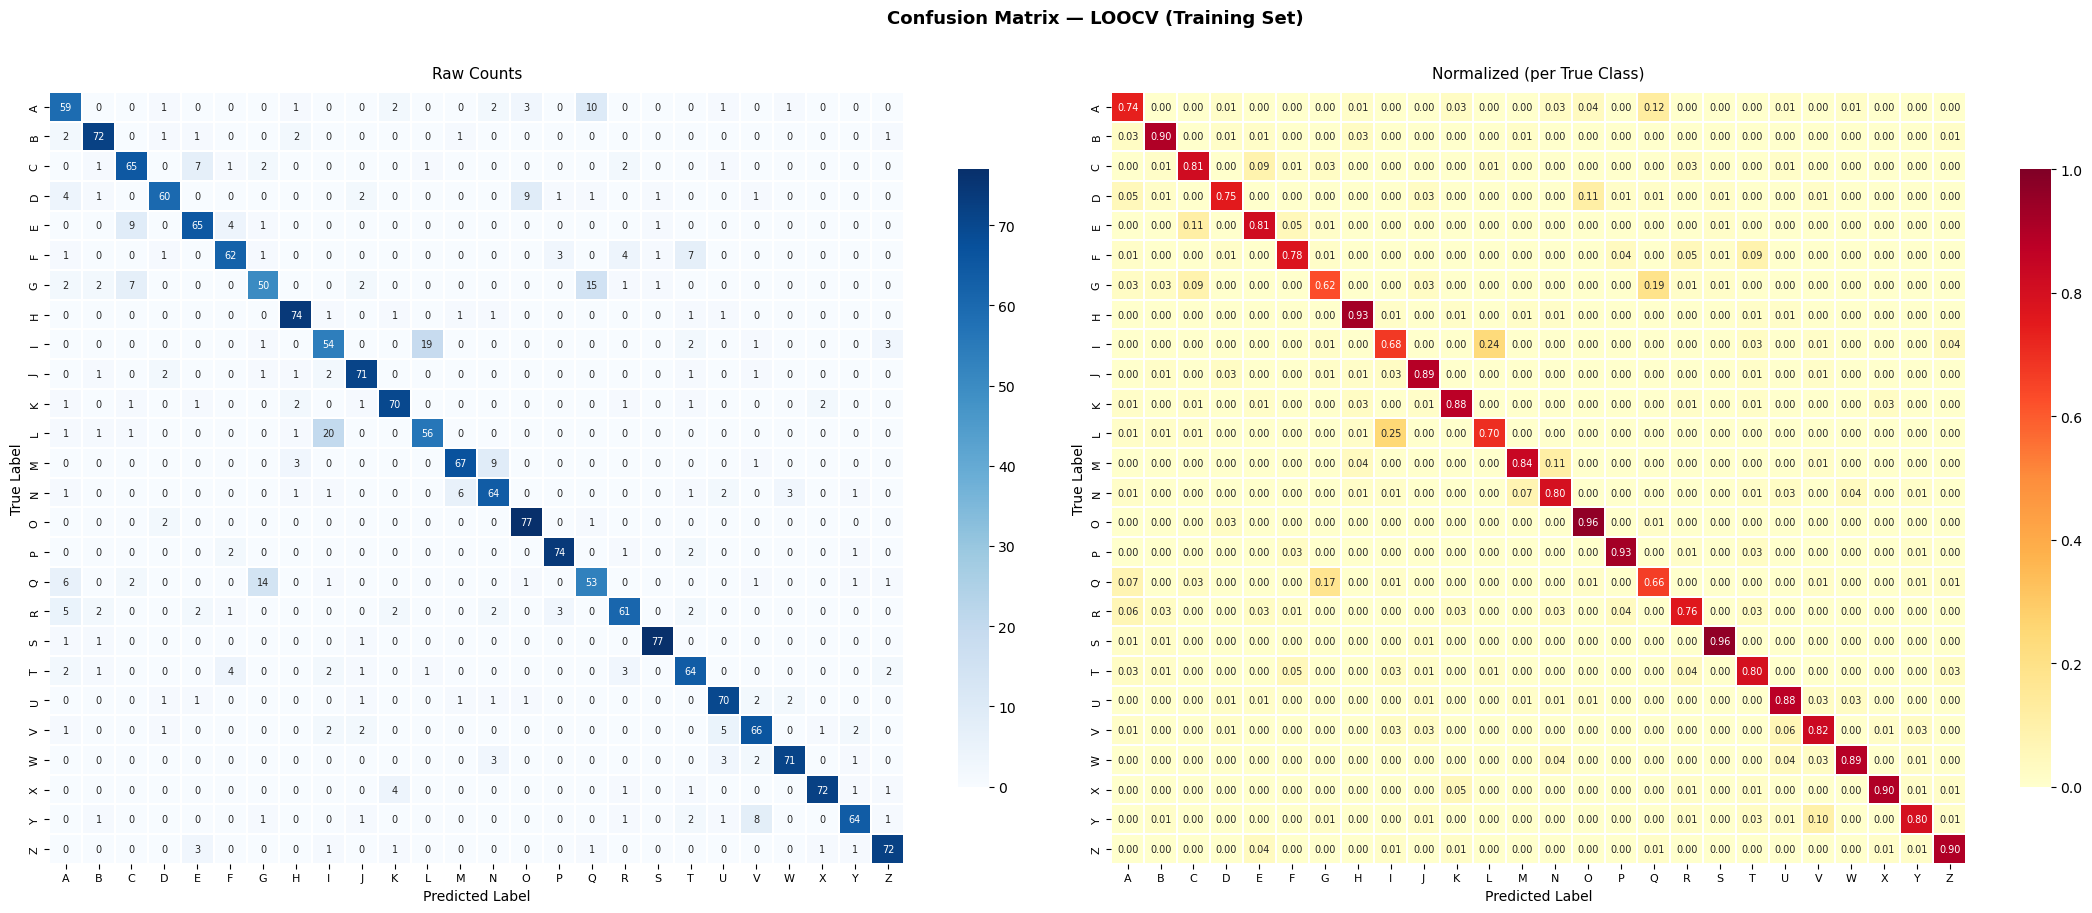

Confusion matrix disimpan: 07_confusion_matrix_loocv.png


In [22]:
def plot_confusion_matrix_dual(y_true, y_pred, class_names, title, filename):
    """Plot confusion matrix: raw counts + normalized side by side."""
    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(1, 2, figsize=(22, 9))
    fig.suptitle(title, fontsize=13, fontweight='bold', y=1.01)

    # ── Raw Counts ─────────────────────────────────────────────────────────────
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[0], linewidths=0.3, linecolor='white',
        annot_kws={'size': 7}, cbar_kws={'shrink': 0.8}
    )
    axes[0].set_title('Raw Counts', fontsize=11, pad=10)
    axes[0].set_xlabel('Predicted Label', fontsize=10)
    axes[0].set_ylabel('True Label', fontsize=10)
    axes[0].tick_params(axis='both', labelsize=8)

    # ── Normalized ─────────────────────────────────────────────────────────────
    sns.heatmap(
        cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
        xticklabels=class_names, yticklabels=class_names,
        ax=axes[1], linewidths=0.3, linecolor='white',
        annot_kws={'size': 7}, vmin=0, vmax=1, cbar_kws={'shrink': 0.8}
    )
    axes[1].set_title('Normalized (per True Class)', fontsize=11, pad=10)
    axes[1].set_xlabel('Predicted Label', fontsize=10)
    axes[1].set_ylabel('True Label', fontsize=10)
    axes[1].tick_params(axis='both', labelsize=8)

    plt.tight_layout()
    plt.savefig(filename, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"Confusion matrix disimpan: {filename}")
    return cm, cm_norm


cm_loocv, cm_loocv_norm = plot_confusion_matrix_dual(
    y_train, y_loocv_pred, CLASS_NAMES,
    'Confusion Matrix — LOOCV (Training Set)',
    '07_confusion_matrix_loocv.png'
)

### 4.5 Confusion Matrix — Test Set (20%)

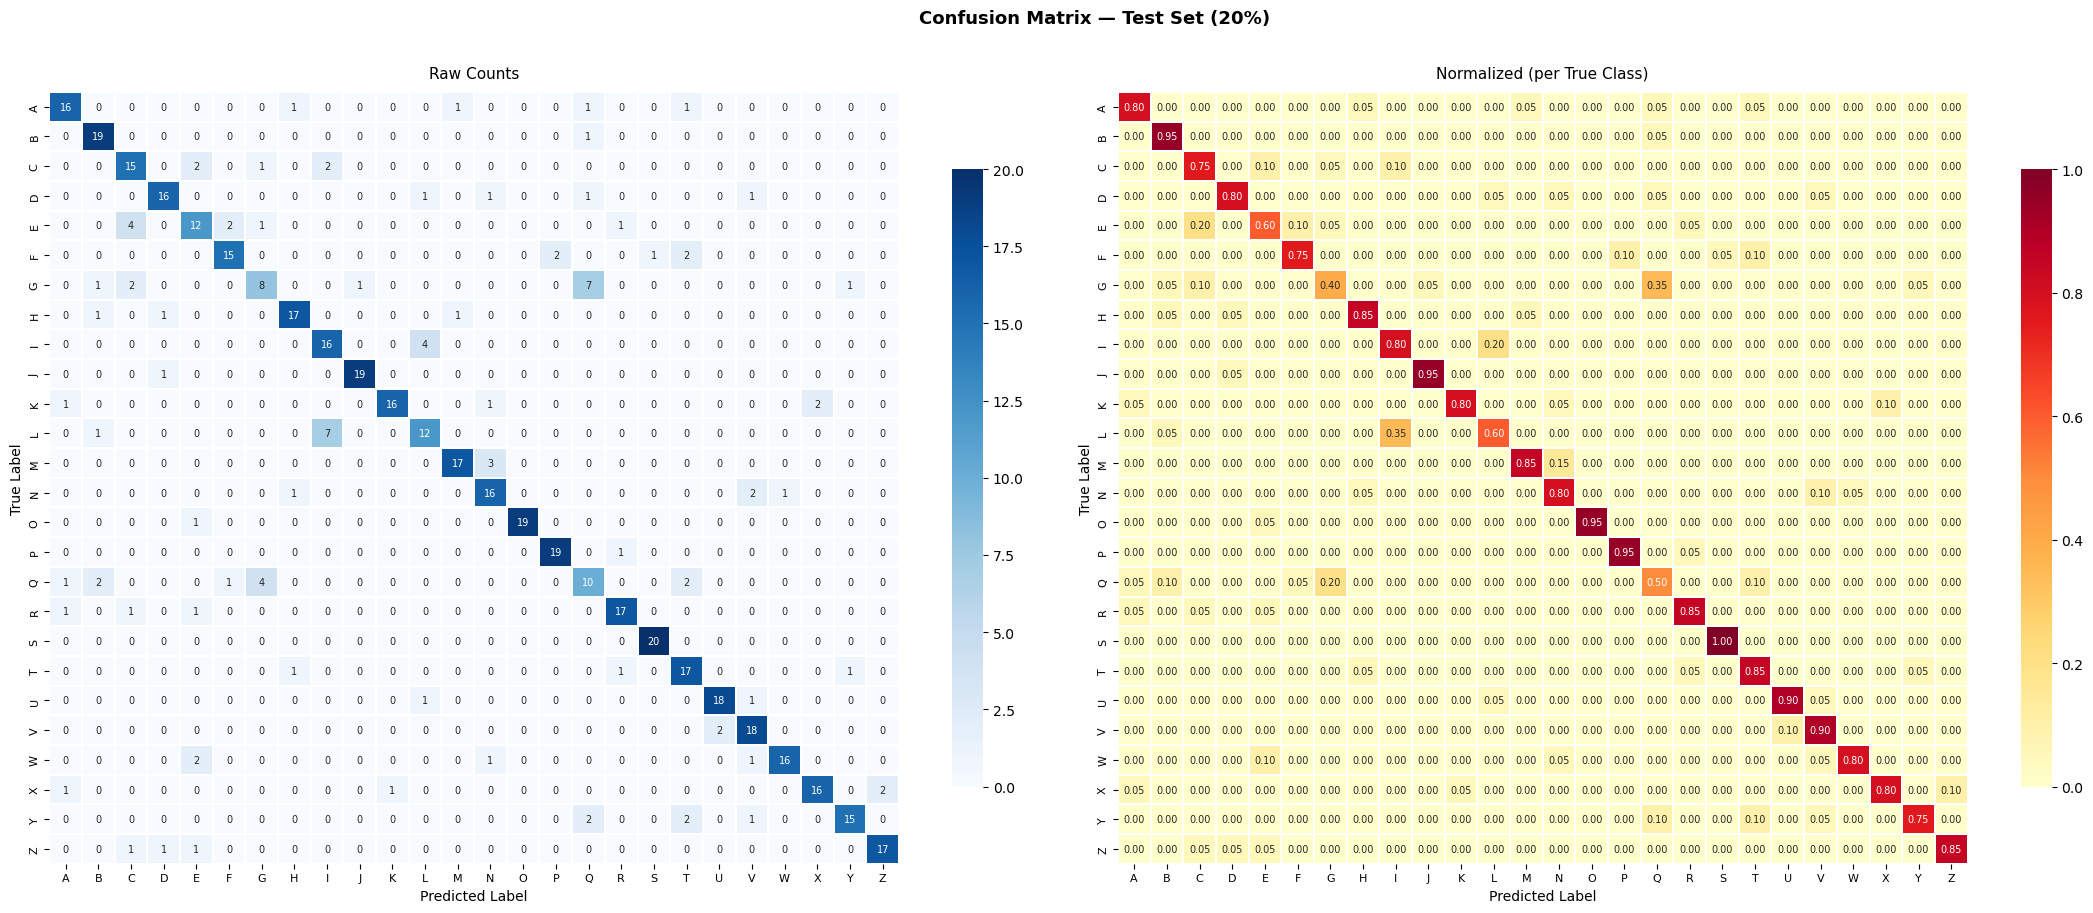

Confusion matrix disimpan: 08_confusion_matrix_test.png


In [23]:
cm_test, cm_test_norm = plot_confusion_matrix_dual(
    y_test, y_test_pred, CLASS_NAMES,
    'Confusion Matrix — Test Set (20%)',
    '08_confusion_matrix_test.png'
)

### 4.6 Per-Class Classification Report

In [24]:
print("=" * 70)
print("  CLASSIFICATION REPORT — LOOCV (Training Set)")
print("=" * 70)
report_loocv = classification_report(
    y_train, y_loocv_pred,
    target_names = CLASS_NAMES,
    digits       = 4,
    zero_division= 0,
)
print(report_loocv)

  CLASSIFICATION REPORT — LOOCV (Training Set)
              precision    recall  f1-score   support

           A     0.6860    0.7375    0.7108        80
           B     0.8675    0.9000    0.8834        80
           C     0.7647    0.8125    0.7879        80
           D     0.8696    0.7500    0.8054        80
           E     0.8125    0.8125    0.8125        80
           F     0.8378    0.7750    0.8052        80
           G     0.7042    0.6250    0.6623        80
           H     0.8706    0.9250    0.8970        80
           I     0.6429    0.6750    0.6585        80
           J     0.8659    0.8875    0.8765        80
           K     0.8750    0.8750    0.8750        80
           L     0.7273    0.7000    0.7134        80
           M     0.8816    0.8375    0.8590        80
           N     0.7805    0.8000    0.7901        80
           O     0.8462    0.9625    0.9006        80
           P     0.9136    0.9250    0.9193        80
           Q     0.6543    0.6625 

In [25]:
print("=" * 70)
print("  CLASSIFICATION REPORT — TEST SET (20%)")
print("=" * 70)
report_test = classification_report(
    y_test, y_test_pred,
    target_names = CLASS_NAMES,
    digits       = 4,
    zero_division= 0,
)
print(report_test)

  CLASSIFICATION REPORT — TEST SET (20%)
              precision    recall  f1-score   support

           A     0.8000    0.8000    0.8000        20
           B     0.7917    0.9500    0.8636        20
           C     0.6522    0.7500    0.6977        20
           D     0.8421    0.8000    0.8205        20
           E     0.6316    0.6000    0.6154        20
           F     0.8333    0.7500    0.7895        20
           G     0.5714    0.4000    0.4706        20
           H     0.8500    0.8500    0.8500        20
           I     0.6400    0.8000    0.7111        20
           J     0.9500    0.9500    0.9500        20
           K     0.9412    0.8000    0.8649        20
           L     0.6667    0.6000    0.6316        20
           M     0.8947    0.8500    0.8718        20
           N     0.7273    0.8000    0.7619        20
           O     1.0000    0.9500    0.9744        20
           P     0.9048    0.9500    0.9268        20
           Q     0.4545    0.5000    0.4

### 4.7 Per-Class F1-Score Comparison

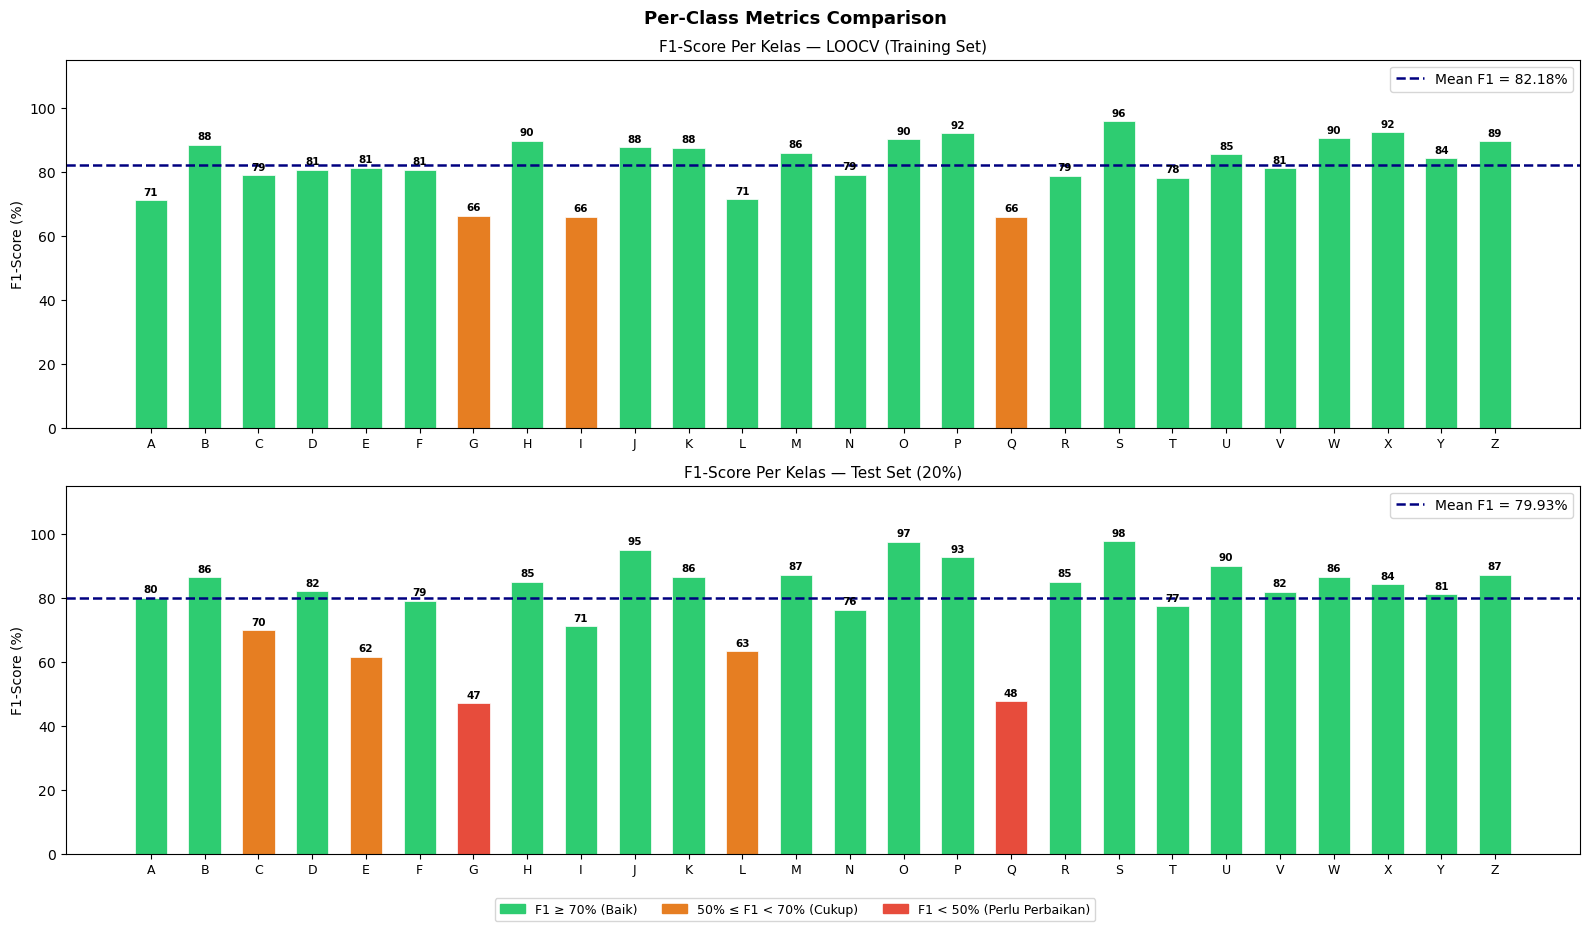

In [26]:
f1_per_loocv = f1_score(y_train, y_loocv_pred, average=None, zero_division=0)
f1_per_test  = f1_score(y_test,  y_test_pred,  average=None, zero_division=0)

prec_per_test = precision_score(y_test, y_test_pred, average=None, zero_division=0)
rec_per_test  = recall_score(y_test, y_test_pred, average=None, zero_division=0)

fig, axes = plt.subplots(2, 1, figsize=(16, 9))
fig.suptitle('Per-Class Metrics Comparison', fontsize=13, fontweight='bold')

x = np.arange(N_CLASSES)
width = 0.6

def bar_colors(vals, thresh_good=0.7, thresh_warn=0.5):
    return ['#2ecc71' if v >= thresh_good else '#e67e22' if v >= thresh_warn else '#e74c3c'
            for v in vals]

# ── LOOCV F1 ──────────────────────────────────────────────────────────────────
bars0 = axes[0].bar(x, f1_per_loocv * 100, width,
                    color=bar_colors(f1_per_loocv), edgecolor='white', linewidth=0.5)
axes[0].axhline(loocv_f1 * 100, color='navy', linestyle='--', linewidth=1.8,
                label=f'Mean F1 = {loocv_f1*100:.2f}%')
axes[0].set_xticks(x); axes[0].set_xticklabels(CLASS_NAMES, fontsize=9)
axes[0].set_ylabel('F1-Score (%)', fontsize=10)
axes[0].set_title('F1-Score Per Kelas — LOOCV (Training Set)', fontsize=11)
axes[0].set_ylim(0, 115); axes[0].legend(fontsize=10)
for bar, val in zip(bars0, f1_per_loocv):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.0f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# ── Test F1 ───────────────────────────────────────────────────────────────────
bars1 = axes[1].bar(x, f1_per_test * 100, width,
                    color=bar_colors(f1_per_test), edgecolor='white', linewidth=0.5)
axes[1].axhline(test_f1 * 100, color='navy', linestyle='--', linewidth=1.8,
                label=f'Mean F1 = {test_f1*100:.2f}%')
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASS_NAMES, fontsize=9)
axes[1].set_ylabel('F1-Score (%)', fontsize=10)
axes[1].set_title('F1-Score Per Kelas — Test Set (20%)', fontsize=11)
axes[1].set_ylim(0, 115); axes[1].legend(fontsize=10)
for bar, val in zip(bars1, f1_per_test):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val*100:.0f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

# Legend warna
from matplotlib.patches import Patch
legend_patches = [
    Patch(color='#2ecc71', label='F1 ≥ 70% (Baik)'),
    Patch(color='#e67e22', label='50% ≤ F1 < 70% (Cukup)'),
    Patch(color='#e74c3c', label='F1 < 50% (Perlu Perbaikan)'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           fontsize=9, bbox_to_anchor=(0.5, -0.04))

plt.tight_layout()
plt.savefig('09_f1_per_class.png', dpi=130, bbox_inches='tight')
plt.show()

### 4.8 Precision, Recall, F1 per Kelas — Detail Test Set

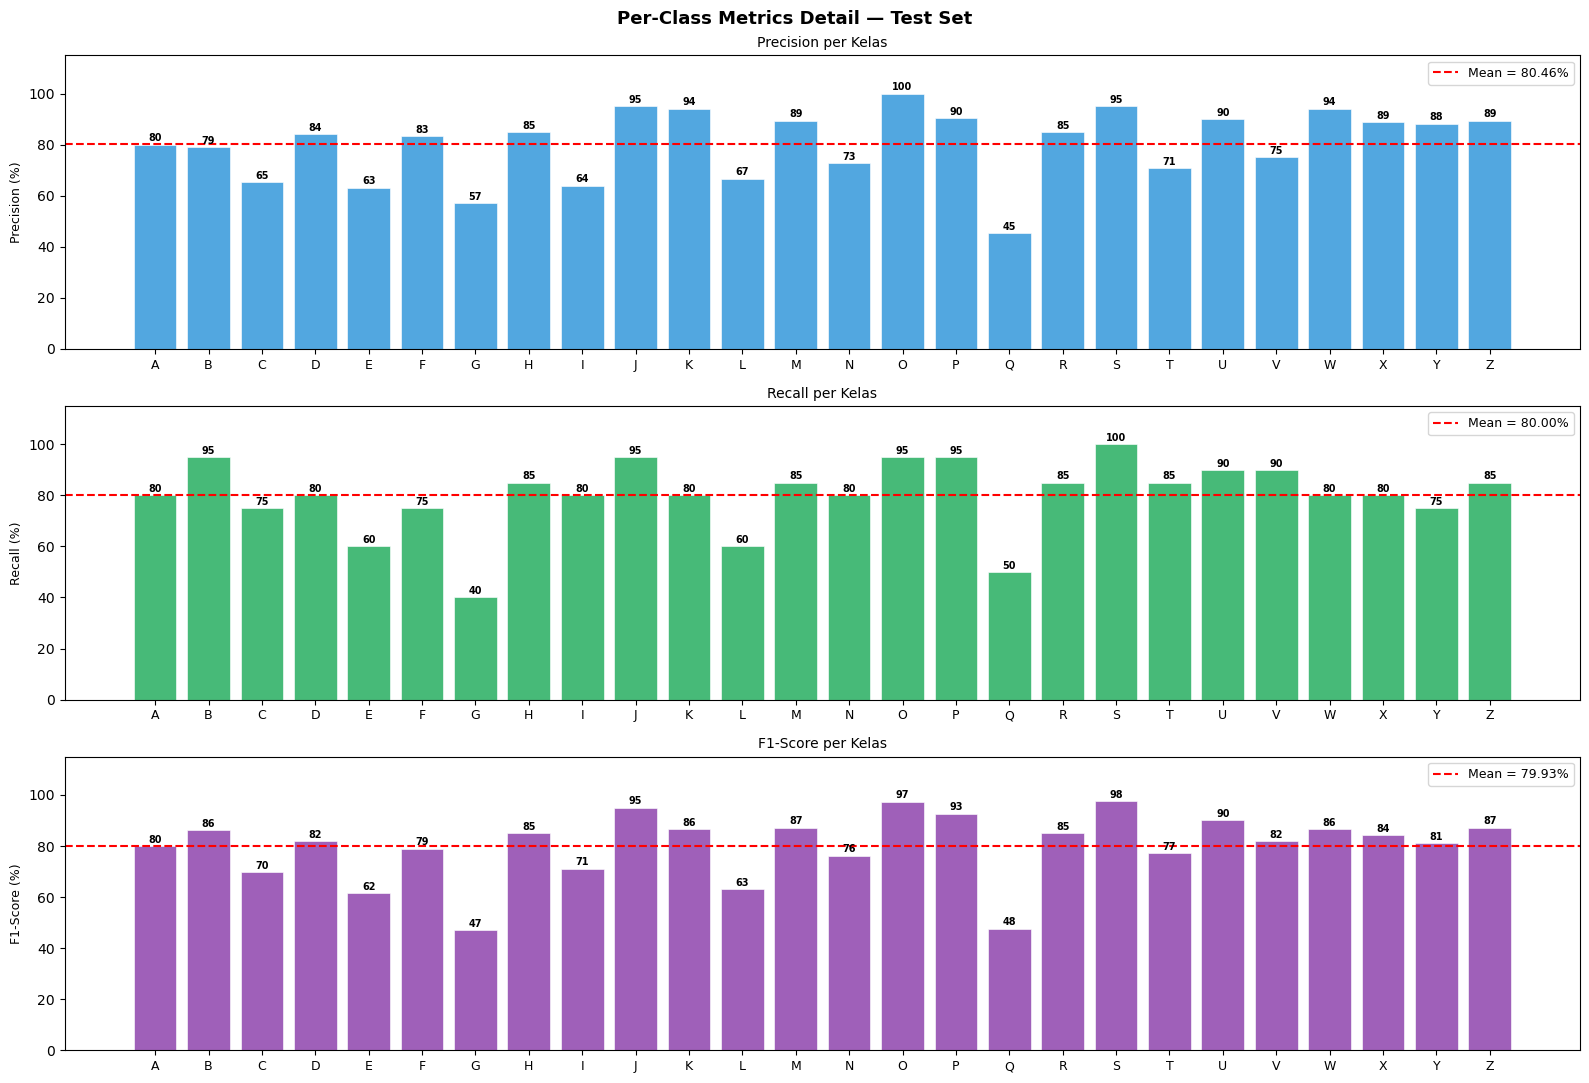

In [27]:
fig, axes = plt.subplots(3, 1, figsize=(16, 11))
fig.suptitle('Per-Class Metrics Detail — Test Set', fontsize=13, fontweight='bold')

metrics_per_class = {
    'Precision': prec_per_test,
    'Recall'   : rec_per_test,
    'F1-Score' : f1_per_test,
}
metric_colors = {'Precision': '#3498db', 'Recall': '#27ae60', 'F1-Score': '#8e44ad'}

for ax, (metric_name, vals) in zip(axes, metrics_per_class.items()):
    bars = ax.bar(x, vals * 100, color=metric_colors[metric_name],
                  alpha=0.85, edgecolor='white', linewidth=0.5)
    mean_val = vals.mean()
    ax.axhline(mean_val * 100, color='red', linestyle='--', linewidth=1.5,
               label=f'Mean = {mean_val*100:.2f}%')
    ax.set_xticks(x); ax.set_xticklabels(CLASS_NAMES, fontsize=9)
    ax.set_ylabel(f'{metric_name} (%)', fontsize=9)
    ax.set_title(f'{metric_name} per Kelas', fontsize=10)
    ax.set_ylim(0, 115); ax.legend(fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val*100:.0f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig('10_per_class_metrics_test.png', dpi=130, bbox_inches='tight')
plt.show()

### 4.9 Analisis Misklasifikasi

In [28]:
# ── Temukan sampel yang salah diklasifikasi ────────────────────────────────────
wrong_idx = np.where(y_test != y_test_pred)[0]
print(f"Total misklasifikasi pada test set: {len(wrong_idx)} / {len(y_test)} sampel")
print(f"Akurasi                           : {(1 - len(wrong_idx)/len(y_test))*100:.2f}%")

# Pasangan kesalahan paling sering
if len(wrong_idx) > 0:
    wrong_true = [CLASS_NAMES[y_test[i]] for i in wrong_idx]
    wrong_pred = [CLASS_NAMES[y_test_pred[i]] for i in wrong_idx]
    wrong_pairs = pd.DataFrame({'True': wrong_true, 'Predicted': wrong_pred})
    pair_counts = (wrong_pairs
                   .groupby(['True', 'Predicted'])
                   .size()
                   .reset_index(name='Count')
                   .sort_values('Count', ascending=False))
    print(f"\nTop-10 pasangan kesalahan paling sering:")
    display(pair_counts.head(10).reset_index(drop=True))

Total misklasifikasi pada test set: 104 / 520 sampel
Akurasi                           : 80.00%

Top-10 pasangan kesalahan paling sering:


,True,Predicted,Count
0,G,Q,7
1,L,I,7
2,Q,G,4
3,I,L,4
4,E,C,4
5,M,N,3
6,V,U,2
7,W,E,2
8,F,P,2
9,C,E,2


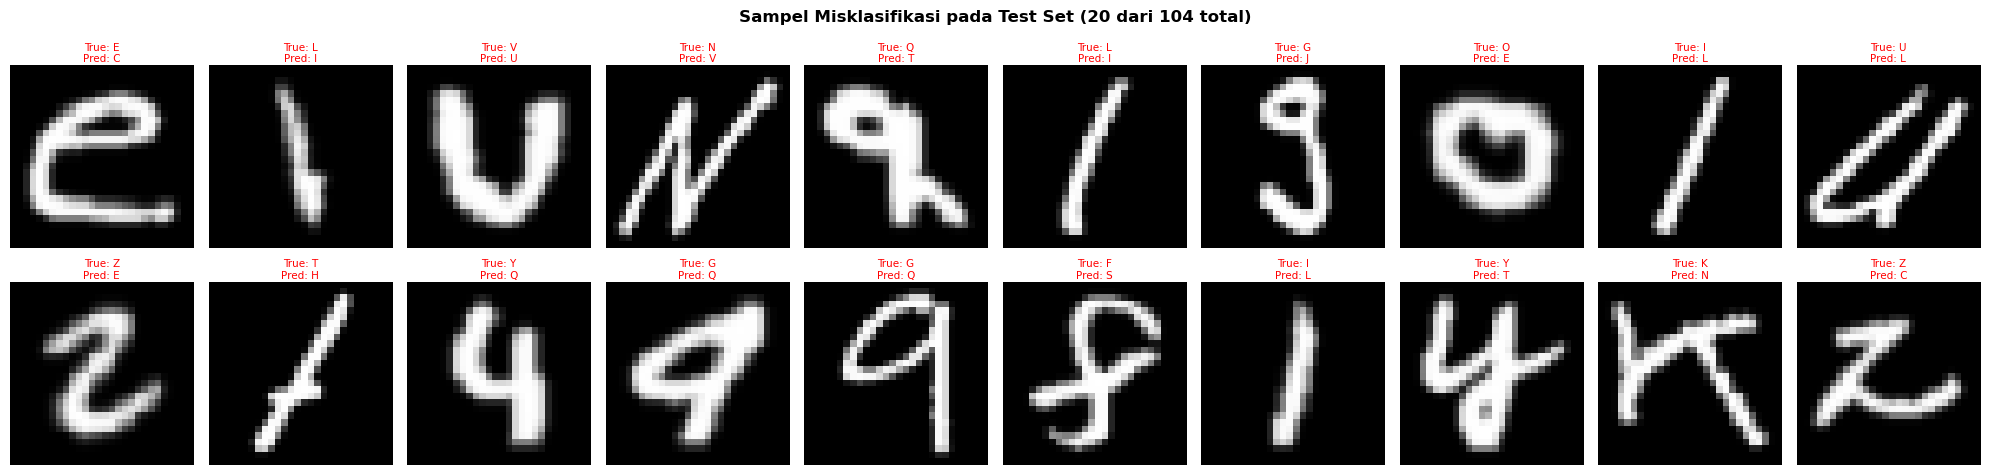

Visualisasi misklasifikasi disimpan.


In [29]:
# ── Visualisasi sampel yang salah diklasifikasi ────────────────────────────────
wrong_idx = np.where(y_test != y_test_pred)[0]
show_n = min(20, len(wrong_idx))

if show_n > 0:
    n_rows = 2; n_cols = 10
    show_n = min(n_rows * n_cols, len(wrong_idx))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5))
    axes = axes.flatten()
    fig.suptitle(
        f'Sampel Misklasifikasi pada Test Set ({show_n} dari {len(wrong_idx)} total)',
        fontsize=12, fontweight='bold'
    )
    for plot_i, idx in enumerate(wrong_idx[:show_n]):
        ax = axes[plot_i]
        ax.imshow(X_test_raw[idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray', interpolation='nearest')
        ax.set_title(
            f'True: {CLASS_NAMES[y_test[idx]]}\nPred: {CLASS_NAMES[y_test_pred[idx]]}',
            fontsize=7.5, color='red', pad=2
        )
        ax.axis('off')
    for ax in axes[show_n:]:
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('11_misclassified_samples.png', dpi=130, bbox_inches='tight')
    plt.show()
    print("Visualisasi misklasifikasi disimpan.")
else:
    print("Tidak ada misklasifikasi — akurasi sempurna pada test set!")

---
## 5. Ringkasan Akhir

In [30]:
# ── Ringkasan Final ────────────────────────────────────────────────────────────
best_p = grid_search.best_params_

print("═" * 65)
print("     EMNIST LETTERS — HOG + SVM: RINGKASAN EKSPERIMEN")
print("═" * 65)
print()
print("  DATASET")
print(f"  ├─ Dataset        : EMNIST Letters (A–Z, 26 kelas)")
print(f"  ├─ Total Sampel   : {TOTAL_SAMPLES} ({N_CLASSES} kelas × {SAMPLES_PER_CLASS} sampel)")
print(f"  ├─ Training Set   : {X_train_raw.shape[0]} sampel (80%)")
print(f"  └─ Test Set       : {X_test_raw.shape[0]} sampel (20%)")
print()
print("  HOG FEATURE EXTRACTION (parameter tuned)")
print(f"  ├─ orientations   : {HOG_PARAMS['orientations']}  (default: 9)")
print(f"  ├─ pixels_per_cell: {HOG_PARAMS['pixels_per_cell']}  (default: (8,8))")
print(f"  ├─ cells_per_block: {HOG_PARAMS['cells_per_block']}  (default: (3,3))")
print(f"  ├─ block_norm     : {HOG_PARAMS['block_norm']}")
print(f"  ├─ transform_sqrt : {HOG_PARAMS['transform_sqrt']}  (default: False)")
print(f"  └─ Panjang vektor : {X_train_hog.shape[1]} fitur")
print()
print("  SVM — PARAMETER TERBAIK (via Grid Search)")
for k, v in best_p.items():
    print(f"  ├─ {k:<15}: {v}")
print(f"  └─ CV Score terbaik : {grid_search.best_score_*100:.2f}% (5-fold CV)")
print()
print("  ┌─────────────────────────┬──────────┬──────────┬──────────┬──────────┐")
print("  │ Split                   │ Accuracy │ Precision│  Recall  │ F1-Score │")
print("  ├─────────────────────────┼──────────┼──────────┼──────────┼──────────┤")
print(f"  │ Training Set (80%)      │ {train_acc*100:6.2f}%  │ {train_prec*100:6.2f}%  │ {train_rec*100:6.2f}%  │ {train_f1*100:6.2f}%  │")
print(f"  │ LOOCV (Training Set)    │ {loocv_acc*100:6.2f}%  │ {loocv_prec*100:6.2f}%  │ {loocv_rec*100:6.2f}%  │ {loocv_f1*100:6.2f}%  │")
print(f"  │ Test Set (20%)          │ {test_acc*100:6.2f}%  │ {test_prec*100:6.2f}%  │ {test_rec*100:6.2f}%  │ {test_f1*100:6.2f}%  │")
print("  └─────────────────────────┴──────────┴──────────┴──────────┴──────────┘")
print()
print("  File output yang dihasilkan:")
outputs = [
    '01_sample_images.png          — Sampel gambar per kelas',
    '02_class_distribution.png     — Distribusi kelas dataset',
    '03_hog_visualization.png      — HOG feature visualization',
    '04_hog_param_comparison.png   — Perbandingan parameter HOG',
    '05_gridsearch_heatmap.png     — Heatmap hasil Grid Search',
    '06_performance_summary.png    — Ringkasan performa model',
    '07_confusion_matrix_loocv.png — Confusion matrix LOOCV',
    '08_confusion_matrix_test.png  — Confusion matrix test set',
    '09_f1_per_class.png           — F1-score per kelas',
    '10_per_class_metrics_test.png — Precision/Recall/F1 per kelas',
    '11_misclassified_samples.png  — Sampel misklasifikasi',
]
for o in outputs:
    print(f"  ├─ {o}")
print("═" * 65)

═════════════════════════════════════════════════════════════════
     EMNIST LETTERS — HOG + SVM: RINGKASAN EKSPERIMEN
═════════════════════════════════════════════════════════════════

  DATASET
  ├─ Dataset        : EMNIST Letters (A–Z, 26 kelas)
  ├─ Total Sampel   : 2600 (26 kelas × 100 sampel)
  ├─ Training Set   : 2080 sampel (80%)
  └─ Test Set       : 520 sampel (20%)

  HOG FEATURE EXTRACTION (parameter tuned)
  ├─ orientations   : 12  (default: 9)
  ├─ pixels_per_cell: (7, 7)  (default: (8,8))
  ├─ cells_per_block: (2, 2)  (default: (3,3))
  ├─ block_norm     : L2-Hys
  ├─ transform_sqrt : True  (default: False)
  └─ Panjang vektor : 432 fitur

  SVM — PARAMETER TERBAIK (via Grid Search)
  ├─ C              : 5
  ├─ gamma          : scale
  ├─ kernel         : rbf
  └─ CV Score terbaik : 81.15% (5-fold CV)

  ┌─────────────────────────┬──────────┬──────────┬──────────┬──────────┐
  │ Split                   │ Accuracy │ Precision│  Recall  │ F1-Score │
  ├───────────────────